In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
trades = pd.read_csv(r"C:\datasets\historical_data.csv")
sentiment = pd.read_csv(r"C:\datasets\fear_greed_index.csv")

In [4]:
print(trades.head())
print(trades.info())

print(sentiment.head())
print(sentiment.info())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [11]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date


In [12]:
trades = trades.dropna(subset=['Closed PnL'])

In [14]:
trades = trades[trades['Coin'].str.contains('BTC', na=False)]

In [15]:
daily_trader_stats = trades.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'count'),
    total_size=('Size USD', 'sum'),
    avg_fee=('Fee', 'mean')
).reset_index()

In [16]:
sentiment_data = sentiment[['date', 'classification']]

In [17]:
sentiment_data['classification'] = sentiment_data['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

C:\Users\Paramanand\AppData\Local\Temp\ipykernel_29840\1666722221.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_data['classification'] = sentiment_data['classification'].replace({


In [18]:
merged_data = daily_trader_stats.merge(
    sentiment_data,
    on='date',
    how='inner'
)

In [19]:
pnl_by_sentiment = merged_data.groupby('classification')['daily_pnl'].mean()
print(pnl_by_sentiment)

classification
Fear       30672.991121
Greed       6447.478074
Neutral     5242.650390
Name: daily_pnl, dtype: float64


In [20]:
merged_data['win'] = merged_data['daily_pnl'] > 0

win_rate = merged_data.groupby('classification')['win'].mean()
print(win_rate)

classification
Fear       0.944444
Greed      0.600000
Neutral    1.000000
Name: win, dtype: float64


In [21]:
size_by_sentiment = merged_data.groupby('classification')['total_size'].mean()
print(size_by_sentiment)

classification
Fear       1.946204e+07
Greed      3.328875e+06
Neutral    6.879434e+05
Name: total_size, dtype: float64


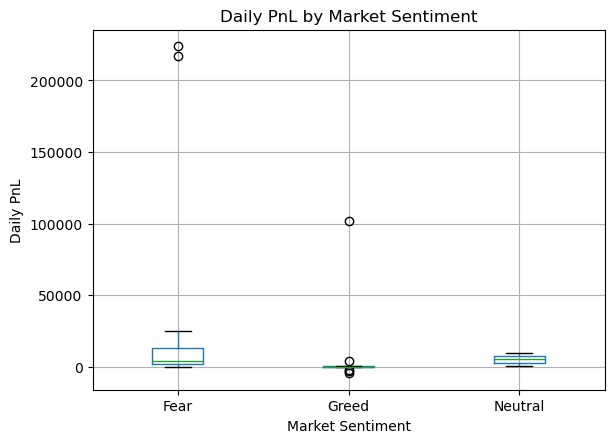

In [22]:
merged_data.boxplot(column='daily_pnl', by='classification')
plt.title('Daily PnL by Market Sentiment')
plt.suptitle('')
plt.xlabel('Market Sentiment')
plt.ylabel('Daily PnL')
plt.show()

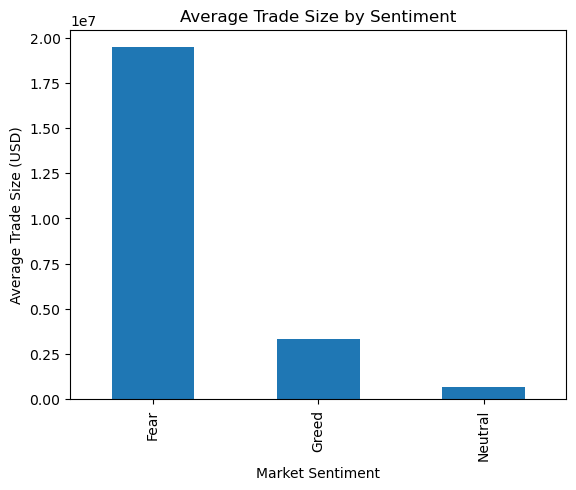

In [23]:
size_by_sentiment.plot(kind='bar')
plt.title('Average Trade Size by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Trade Size (USD)')
plt.show()

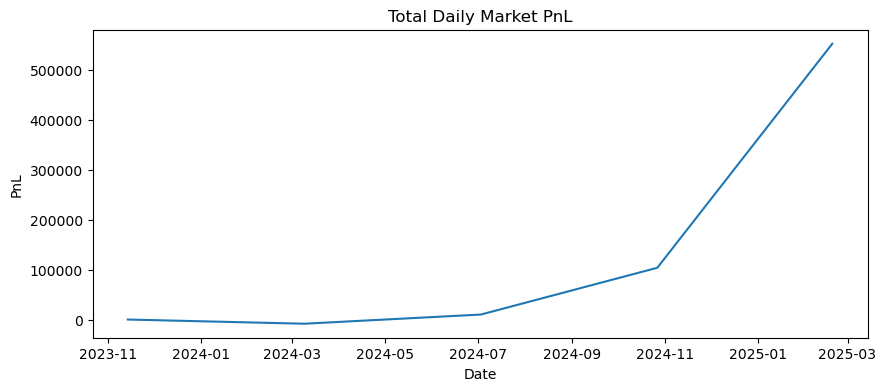

In [24]:
daily_market_pnl = merged_data.groupby('date')['daily_pnl'].sum()

daily_market_pnl.plot(figsize=(10, 4))
plt.title('Total Daily Market PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.show()

In [25]:
top_accounts = (
    merged_data.groupby('Account')['daily_pnl']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

top_traders_data = merged_data[merged_data['Account'].isin(top_accounts)]

print(
    top_traders_data.groupby('classification')['daily_pnl'].mean()
)

classification
Fear       32499.790842
Greed       7688.536239
Neutral     5242.650390
Name: daily_pnl, dtype: float64
